# Final Evaluation and Ultimate Judgement

Task 1 uses the plain CNN chosen in Notebook 02. **Run All verifies and reads saved evidence.** Run the separate refit, holdout prediction, and scoring commands first. This notebook stops if evidence is missing or changed. It does not train, run inference, open raw protected labels, or write predictions.

Task 2 and Task 3 provide small workflow references. Their scores answer different questions, so they are not a ranking of owners.

## 1. Final-evaluation contract

One canonical split: `data/processed/splits.csv`. Refit uses development only. Predict all 5,778 holdout images before joining labels. Exclude the 61 quarantined rows. The Task 1 holdout is opened once for scoring. Score once with the fixed 124-label metric and keep the same checkpoint for official prediction.

Task 3 and Task 2 have already accessed this shared holdout for their targets. Task 1's plain-CNN choice came from development CV. This is a same-source holdout, not proof of performance on new customer photos.

In [1]:
import json
import os
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from fashion.config import ROOT
from fashion.task1.final_evaluation_runner import audit_final_evaluation

project_root = Path(os.environ.get("FASHION_PROJECT_ROOT", str(ROOT))).resolve()
evidence = audit_final_evaluation(project_root)
tables = evidence["tables"]
freeze = evidence["freeze"]
display(Markdown("**Verified saved Task 1 evaluation.** No models were run by this notebook."))

**Verified saved Task 1 evaluation.** No models were run by this notebook.

## 2. Frozen inputs from task notebooks

Task 1's identity below comes from the saved freeze and model manifest. For the other owners, follow their own saved-evidence notebooks. These links do not imply we reran or reverified their experiments.

In [2]:
display(pd.DataFrame([
    {"task": "1: articleType", "workflow": "This verified evidence package", "reference": "02_task1_article_type.ipynb"},
    {"task": "2: season", "workflow": "Owner's saved final evaluation", "reference": "06_task2_season_evaluation.ipynb"},
    {"task": "3: gender / usage", "workflow": "Owner's saved evaluation and acceptance limits", "reference": "04_task3_final_evaluation.ipynb"},
]))
display(pd.DataFrame([{
    "candidate": freeze["config"]["candidate_id"], "classes": len(freeze["class_names"]),
    "preprocessing": freeze["config"]["preprocessing_id"], "frozen_at": freeze["created_at"],
}]))

,task,workflow,reference
0,1: articleType,This verified evidence package,02_task1_article_type.ipynb
1,2: season,Owner's saved final evaluation,06_task2_season_evaluation.ipynb
2,3: gender / usage,Owner's saved evaluation and acceptance limits,04_task3_final_evaluation.ipynb


,candidate,classes,preprocessing,frozen_at
0,task1_cnn_no_aug_unweighted_v1,124,task1_rgb_60x80_no_aug_v1,2026-09-09T03:16:44.394418+00:00


## 3. Select winning runs and lock decisions

**Chosen on 9 September 2026:** `task1_cnn_no_aug_unweighted_v1`. It had the best mean five-fold macro-F1, 0.5315, and pooled OOF macro-F1, 0.5569. Augmentation had lower fold variation but a lower mean, 0.5218. Strong inverse-frequency weighting was worse. These are development results.

Use Notebook 02 for the full five-model comparison and the restored training ledger, `results/runs.csv`. The 80 Task 1 run records were recovered from the original backup; other tasks' records were preserved. Do not change the chosen model after seeing the tables below.

## 4. Confirm metric and CV evidence

Macro-F1 gives equal weight to each of 124 labels, including zero F1 for absent labels. The five-fold mean and pooled OOF score are different calculations. Neither is the final holdout score. Strong Top-1 and Top-5 scores can hide poor rare-class results.

The development tables below are hash-checked when present in the freeze. Detailed comparisons remain in Notebook 02.

In [3]:
for name, artifact in freeze.get("development_evidence", {}).items():
    display(Markdown(f"**Development evidence: {name}**"))
    display(pd.read_csv(project_root / artifact["path"], keep_default_na=False))

**Development evidence: classical_comparison**

,candidate_id,hog_id,model_family,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,top1_accuracy_mean,top1_accuracy_std,top5_accuracy_mean,top5_accuracy_std
0,task1_gray_hog_ppc10_v1-knn-k3-distance,task1_gray_hog_ppc10_v1,task1_hog_knn_v1,0.502289,0.014018,0.786037,0.004673,0.795533,0.004801,0.895218,0.003960
1,task1_gray_hog_ppc10_v1-linear-svm-c0.1-balanced,task1_gray_hog_ppc10_v1,task1_hog_linear_svm_v1,0.488857,0.016529,0.780246,0.005622,0.776462,0.004778,0.944588,0.003859


**Development evidence: comparison**

,candidate_id,preprocessing_id,loss_id,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,top1_accuracy_mean,top1_accuracy_std,top5_accuracy_mean,top5_accuracy_std
0,task1_cnn_no_aug_unweighted_v1,task1_rgb_60x80_no_aug_v1,cross_entropy_unweighted_v1,0.531473,0.033070,0.838106,0.007759,0.842186,0.007267,0.977969,0.002739
1,task1_cnn_mild_aug_unweighted_v1,task1_rgb_60x80_mild_aug_v1,cross_entropy_unweighted_v1,0.521784,0.015783,0.837349,0.006263,0.842918,0.006338,0.980929,0.002186
2,task1_cnn_mild_aug_balanced_weighted_v1,task1_rgb_60x80_mild_aug_v1,cross_entropy_balanced_class_weighted_v1,0.456413,0.018133,0.713878,0.024425,0.691510,0.024893,0.952491,0.007479


**Development evidence: oof_metrics**

,candidate_id,preprocessing_id,loss_id,macro_f1_124,weighted_f1,top1_accuracy,top5_accuracy
0,task1_cnn_no_aug_unweighted_v1,task1_rgb_60x80_no_aug_v1,cross_entropy_unweighted_v1,0.556926,0.839208,0.842187,0.977970
1,task1_cnn_mild_aug_unweighted_v1,task1_rgb_60x80_mild_aug_v1,cross_entropy_unweighted_v1,0.540755,0.838582,0.842919,0.980929
2,task1_cnn_mild_aug_balanced_weighted_v1,task1_rgb_60x80_mild_aug_v1,cross_entropy_balanced_class_weighted_v1,0.466383,0.714510,0.691514,0.952491


## 5. Refit on all development

The final run starts from random weights and uses the fixed 20-epoch recipe, seed 2753, Adam and OneCycleLR. It uses no validation-based stopping or checkpoint choice. Epoch 20 is the submitted checkpoint. Full-development fitting is a new registered training run; it does not replace the earlier fold runs.

In [4]:
model_record = next(item for item in freeze["inputs"] if item["path"] == "models/task1_article_type.manifest.json")
model_manifest = json.loads((project_root / model_record["path"]).read_text(encoding="utf-8"))
display(model_manifest)

{'bundle': {'path': 'models/task1_article_type.pt',
  'sha256': 'c3d219980590a76aab7c58ad4d564a525d243056183d7857de2ac15ff38000ad'},
 'candidate_id': 'task1_cnn_no_aug_unweighted_v1',
 'canonical_inputs': {'config': {'path': 'configs/task1/final_evaluation.json',
   'sha256': '0c273763d6b849facd8a876d7ab159df902773251f7487143cffbc0bdac8982a'},
  'label_map': {'path': 'data/processed/label_maps.json',
   'sha256': '51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8f4dd15b94c1996a327'},
  'splits': {'path': 'data/processed/splits.csv',
   'sha256': 'd76a49c6dc7999b4f286e94838a92c603d68c4f66179fde081028948f6a187db'}},
 'development_rows': 32773,
 'final_epoch': 20,
 'history': {'path': 'results/evidence/task1/development_refit/training_history.csv',
  'sha256': '5ada5038cc43a80d0cb9ed17122c1878386f42df0102a0e08d6fe2bf025ab5bb'},
 'model_family': 'task1_small_cnn_v1',
 'run_id': 'task1-cnn-task1_cnn_no_aug_unweighted_v1-final-refit-fall-s2753-25828f9946dd',
 'schema_version': 1,
 'scratch': Tr

## 6. Fit final preprocessing on all development

The saved transform converts to RGB and pads/resizes to 60 by 80 pixels. Normalization means and standard deviations come only from development images. There is no random augmentation. The bundle contains the transform settings and fitted development-ID digest, so inference reuses the exact training transform.

In [5]:
display(freeze["config"]["refit"])

{'augmentation_used': False,
 'batch_size': 128,
 'candidate_id': 'task1_cnn_no_aug_unweighted_v1',
 'checkpoint_rule': 'fixed_last_epoch',
 'epochs': 20,
 'grad_clip_norm': 1.0,
 'loss_id': 'cross_entropy_unweighted_v1',
 'max_lr': 0.001,
 'model_family': 'task1_small_cnn_v1',
 'normalization_scope': 'development_only',
 'preprocessing_id': 'task1_rgb_60x80_no_aug_v1',
 'schema_version': 1,
 'scratch': True,
 'seed': 2753,
 'target': 'articleType',
 'validation_used': False,
 'weight_decay': 1e-05}

## 7. Lock final checkpoints and outputs

These file hashes connect the model, class order, split, contract and source code to the saved predictions. A changed input makes replay fail. Copy the whole package when moving to another machine.

In [6]:
display(pd.DataFrame(freeze["inputs"]))

,path,sha256
0,configs/task1/final_evaluation.json,0c273763d6b849facd8a876d7ab159df902773251f7487...
1,data/processed/splits.csv,d76a49c6dc7999b4f286e94838a92c603d68c4f66179fd...
2,data/processed/label_maps.json,51b7623c3a2c1a8f9ebb9b0d8b4b8a50a24ea57522c1f8...
3,models/task1_article_type.pt,c3d219980590a76aab7c58ad4d564a525d243056183d78...
4,models/task1_article_type.manifest.json,6000ce48f8d31e8c1ef43518fb4c42096fa124d84d0f93...
...,...,...
113,src/fashion/train/task3_usage_two_stage.py,cc4c791adc52235c47258893ef95e73f5548ea517a1876...
114,src/fashion/train/task3_usage_two_stage_fit.py,59d5ba4e43ee66d3ec60bb4397c4ce0aeba0339a93f54e...
115,src/fashion/train/task3_usage_two_stage_runtim...,35cfc842dbde29a1066591f76d6112d57698ccdbe28792...
116,src/fashion/train/task3_usage_v3_setup.py,9f5e829bd1627917d6f75861c22284017dec37c05f897b...


## 8. Open internal holdout once

The prediction receipt records label-free clean and degraded-image predictions. The later unlock receipt links back to that exact receipt. The protected loader joins the shared label columns, but Task 1 scoring uses only `articleType`. No threshold, epoch or alternative model is selected here.

In [7]:
display(evidence["prediction_receipt"])
unlock_record = evidence["evaluation_manifest"]["unlock_receipt"]
display(json.loads((project_root / unlock_record["path"]).read_text(encoding="utf-8")))

{'completed_at': '2026-09-09T03:20:54.396121+00:00',
 'cost': {'path': 'results/evidence/task1/final_evaluation/cost.json',
  'sha256': '3c0f715f5b6c8254e18ff5ccb06691f2315b640de05033da065052112962fed6'},
 'freeze': {'path': 'results/evidence/task1/final_evaluation/freeze.json',
  'sha256': '9e828bc4a11a91ac38cebfdd92a4b73fb5ea6ebf57835296414c658f0b8e178b'},
 'labels_accessed': False,
 'predictions': [{'condition': 'clean',
   'path': 'results/evidence/task1/final_evaluation/holdout_predictions.csv',
   'sha256': 'bea0fe27b02fca41669320f3d9a9c51aaae1f08ea01ab6846d7a74a3b180e7ab'},
  {'condition': 'jpeg_quality_85',
   'path': 'results/evidence/task1/final_evaluation/holdout_jpeg_quality_85.csv',
   'sha256': '2832c7ba8178db0c4bd46d6f238ed2004364af14587d88f4cfbb354e2ed1c3e9'},
  {'condition': 'brightness_0_85',
   'path': 'results/evidence/task1/final_evaluation/holdout_brightness_0_85.csv',
   'sha256': '4b6ae43ae78adcf27c5b215ef2fb3fc6d902e87376f855018325b791a9378b73'},
  {'condition'

{'access': 'shared protected loader joins all target columns; scoring uses articleType only',
 'prediction_receipt': {'path': 'results/evidence/task1/final_evaluation/prediction_receipt.json',
  'sha256': 'f71175a24386e6a55965295e800dcb99ef52256c2cd4d1410e5c50601f6f5223'},
 'prior_access': 'Other targets have already used the shared holdout. Task 1 selected the plain CNN from development CV before this evaluation. Do not change this choice using holdout scores.',
 'target': 'articleType',
 'unlocked_at': '2026-09-09T03:20:59.747049+00:00'}

## 9. Independent holdout evaluation

**Question:** How well does this frozen model handle the saved holdout?

Read the scorecard together with all-class support. Intervals resample whole product families 10,000 times, preserving related images together. They describe sampling uncertainty on this dataset; they do not cover new photo styles or label mistakes.

In [8]:
display(tables["metrics"].round(4))
display(tables["uncertainty"].round(4))
display(tables["per_class"].sort_values(["f1", "support"]).round(4))

,rows,macro_f1,weighted_f1,top1_accuracy,top5_accuracy
0,5778,0.5752,0.8469,0.8493,0.9843


,metric,estimate,lower_95,upper_95,families,replicates
0,macro_f1,0.5752,0.4799,0.5553,4110,10000
1,weighted_f1,0.8469,0.8359,0.8579,4110,10000
2,top1_accuracy,0.8493,0.8386,0.8598,4110,10000
3,top5_accuracy,0.9843,0.9804,0.9877,4110,10000


,class_index,class_name,precision,recall,f1,support,development_count
1,1,Baby Dolls,0.0,0.0,0.0,0,2
7,7,Body Wash and Scrub,0.0,0.0,0.0,0,1
20,20,Compact,0.0,0.0,0.0,0,4
21,21,Concealer,0.0,0.0,0.0,0,2
23,23,Cushion Covers,0.0,0.0,0.0,0,1
...,...,...,...,...,...,...,...
103,103,Swimwear,1.0,1.0,1.0,2,15
8,8,Booties,1.0,1.0,1.0,3,9
68,68,Nail Polish,1.0,1.0,1.0,3,16
22,22,Cufflinks,1.0,1.0,1.0,6,38


## 10. Error, robustness, and cost analysis

**Question:** Where does it fail, and what can the app support?

Confusion pairs show both error count and share of the true class. Error IDs let us trace a prediction to its saved source image. Rare-class bands come from development counts, not holdout outcomes. Slice macro-F1 still includes all 124 labels; use it with support and accuracy.

The same fixed JPEG, brightness and blur probes as Task 2 describe sensitivity. They do not simulate every customer photo. Raw-confidence reliability and risk versus coverage are diagnostics only; no automatic-review threshold is chosen here.

CPU timing includes image decoding and preprocessing, excludes loading, and reports the machine and thread count. Batch throughput is one measured batch, not a service load test.

**confusion pairs**

,articleType,predicted_label,errors,true_class_support,share_of_true_class
0,Tshirts,Tops,59,1020,0.0578
1,Sports Shoes,Casual Shoes,42,300,0.1400
2,Casual Shoes,Sports Shoes,41,404,0.1015
3,Tops,Tshirts,39,243,0.1605
4,Flats,Heels,23,62,0.3710
5,Heels,Flats,21,158,0.1329
6,Shirts,Tshirts,17,464,0.0366
7,Sandals,Flip Flops,17,130,0.1308
8,Formal Shoes,Casual Shoes,15,91,0.1648
9,Tops,Shirts,14,243,0.0576


**errors**

,id,articleType,product_family_group,mode,predicted_label,confidence,correct
0,1550,Footballs,family_c27484c7087191b2,RGB,Sports Shoes,0.9927,False
1,1561,Tshirts,family_8bcefa497af26e68,RGB,Tops,0.9114,False
2,1579,Jackets,family_ec11f26d671bcc37,RGB,Shirts,0.9842,False
3,1587,Sports Shoes,family_0252fa3e9d9c8c2c,RGB,Casual Shoes,0.9578,False
4,1634,Sports Shoes,family_ca05bc2bf73745fe,RGB,Casual Shoes,1.0000,False
5,1757,Tshirts,family_507c38cb8a975a83,RGB,Handbags,0.6971,False
6,1806,Sandals,family_a78000a5ff630601,RGB,Sports Shoes,0.6048,False
7,1862,Tshirts,family_169564455792f758,RGB,Shirts,0.9961,False
8,1918,Backpacks,family_54e87e2783378cd8,RGB,Handbags,0.9999,False
9,1932,Casual Shoes,family_01a0123885ebec5b,RGB,Sports Shoes,0.9996,False


**slices**

...

**reliability**

,bin,rows,mean_confidence,accuracy
0,3,6,0.3700,0.3333
1,4,27,0.4539,0.2593
2,5,154,0.5499,0.4221
3,6,135,0.6472,0.4222
4,7,157,0.7500,0.5414
5,8,255,0.8556,0.5882
6,9,5044,0.9941,0.9003


**risk coverage**

,coverage,rows,error_rate
0,0.1000,578,0.0087
1,0.2001,1156,0.0078
2,0.3001,1734,0.0092
3,0.4001,2312,0.0130
4,0.5000,2889,0.0180
5,0.6000,3467,0.0294
6,0.7001,4045,0.0475
7,0.8001,4623,0.0753
8,0.9001,5201,0.1079
9,1.0000,5778,0.1507


{'batch_images_per_second': 263.07103370341935,
 'batch_one_ms_median': 5.577700037974864,
 'batch_one_ms_p95': 5.956080066971481,
 'batch_rows': 128,
 'batch_seconds': 0.4865605999948457,
 'batch_size': 128,
 'checkpoint_bytes': 1912377,
 'device': 'cpu',
 'image_decode_included': True,
 'latency_samples_ms': [5.529099958948791,
  5.5902000749483705,
  5.728499963879585,
  5.845600040629506,
  5.960400099866092,
  5.941600073128939,
  5.458500003442168,
  5.374999949708581,
  5.377499968744814,
  5.354400025680661,
  5.335499998182058,
  5.667499965056777,
  5.792199983261526,
  5.950800026766956,
  5.73830003850162,
  5.3527000127360225,
  5.436800071038306,
  5.884099984541535,
  5.800799932330847,
  5.798500031232834,
  5.961099988780916,
  5.285699968226254,
  5.565200001001358,
  5.741899949498475,
  5.716799991205335,
  5.155800026841462,
  4.2573000537231565,
  4.0194999892264605,
  4.0117999305948615,
  5.509100039489567],
 'loading_included': False,
 'machine': 'Windows-11-10

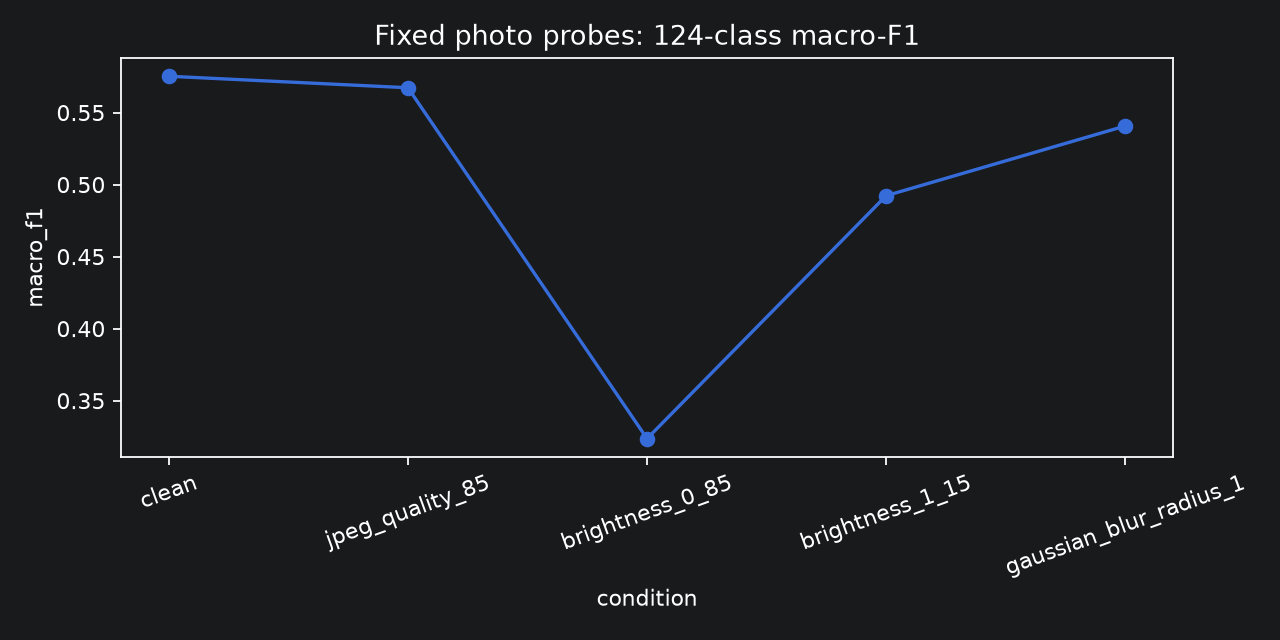

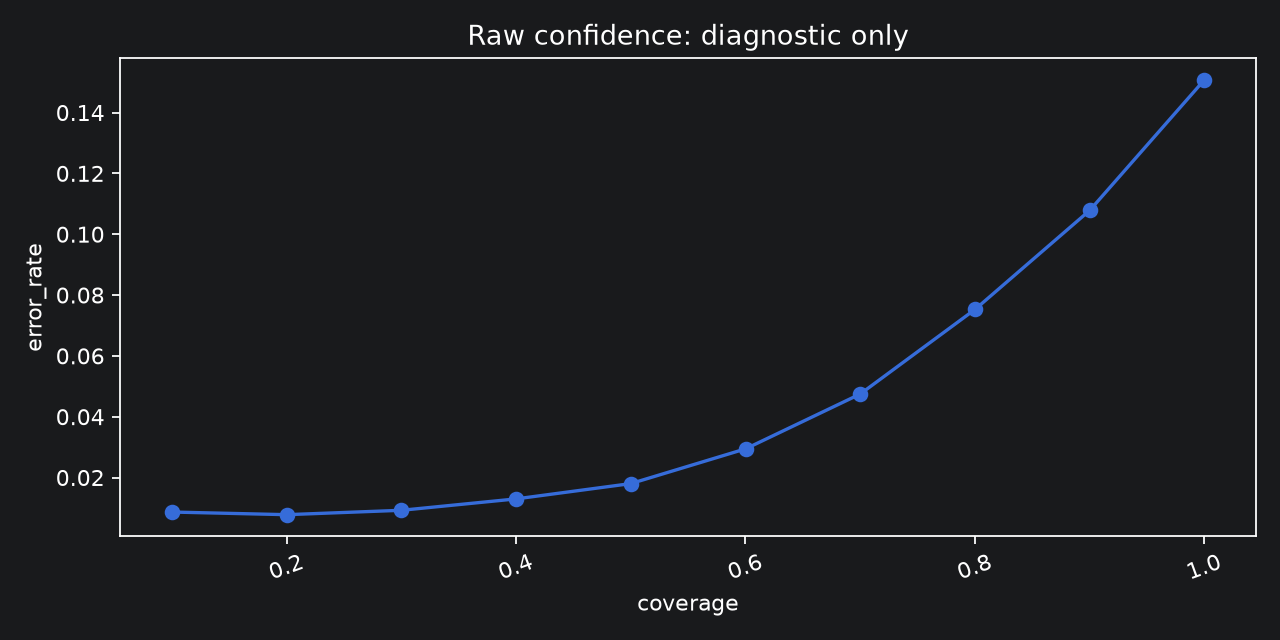

In [9]:
for name in ["confusion_pairs", "errors", "slices", "robustness", "reliability", "risk_coverage"]:
    display(Markdown(f"**{name.replace('_', ' ')}**"))
    display(tables[name].head(20).round(4))
display(evidence["cost"])
for artifact in evidence["evaluation_manifest"]["figures"]:
    display(Image(filename=str(project_root / artifact["path"])))

## 11. Ultimate judgement by required output

Use the measured statements below as the start of the final judgement. High Top-5 coverage may support a suggestion list; it does not establish safe automatic labelling. Check the small and absent classes before claiming coverage of the full catalogue.

For Assessment 3, show the five-model comparison, one common failure, and one practical limit. A useful extension is Top-5 suggestions with human review. Any review rule must first be fitted on development evidence and later tested on new labelled data. See `docs/task1-evaluation-plan.md` for literature and presentation notes.

Task 2 and Task 3 need their own target-specific judgement. Link their notebooks instead of comparing their scores directly with Task 1.

In [10]:
metric = tables["metrics"].iloc[0]
classes = tables["per_class"]
zero_f1 = int(classes["f1"].eq(0).sum())
absent = int(classes["support"].eq(0).sum())
stress = tables["robustness"].set_index("condition")
change = float(stress["macro_f1"].min() - stress.loc["clean", "macro_f1"])
display(Markdown(
    f"On **{int(metric['rows']):,} holdout images**, macro-F1 was **{metric['macro_f1']:.4f}**. "
    f"Top-1 accuracy was **{metric['top1_accuracy']:.2%}** and Top-5 accuracy was **{metric['top5_accuracy']:.2%}**. "
    f"**{zero_f1} labels had zero F1**, including **{absent} labels absent from this holdout**. "
    f"The lowest fixed photo-probe macro-F1 differed from clean by **{change:+.4f}**. "
    "These results describe catalogue images from the saved split. They do not prove customer-photo performance or a safe confidence threshold."
))
display(evidence["evaluation_manifest"]["limitations"])

On **5,778 holdout images**, macro-F1 was **0.5752**. Top-1 accuracy was **84.93%** and Top-5 accuracy was **98.43%**. **32 labels had zero F1**, including **14 labels absent from this holdout**. The lowest fixed photo-probe macro-F1 differed from clean by **-0.2516**. These results describe catalogue images from the saved split. They do not prove customer-photo performance or a safe confidence threshold.

['same-source catalogue holdout',
 'other targets accessed shared holdout earlier',
 '124-class macro-F1 includes absent-class zeros',
 'family bootstrap intervals do not measure distribution shift',
 'photo probes do not establish customer-photo performance',
 'confidence is uncalibrated; no review threshold was selected']

## 12. Official predictions and system handoff

After scoring, run `predict-test` with the same checkpoint. The Task 1 export is `results/article_type_test_predictions.csv` with `id,articleType`. It must contain 5,829 rows in template order. The teacher supplied no labels for these images, so this is prediction, not another accuracy test.

The group must separately validate and merge the other owners' outputs by ID. The final group file has `id,gender,articleType,season,usage` with no blanks. Preserve the teacher's source template.

In [11]:
official = evidence["test_prediction_receipt"]
if official is None:
    display(Markdown("**Official export pending.** Run `scripts/build_task1_final_evaluation.py predict-test` after reviewing this evaluation."))
else:
    display(official)
    display(pd.read_csv(project_root / official["output"]["path"], keep_default_na=False).head())

{'combined_submission_status': 'pending validated outputs from the other owners; source template unchanged',
 'completed_at': '2026-09-09T03:22:53.969112+00:00',
 'evaluation_manifest': {'path': 'results/evidence/task1/final_evaluation/evaluation_manifest.json',
  'sha256': '50c5fef00f14928bbf4a4513fb953dc8a83248c37cb0dcb0dd6b757f06a2f50d'},
 'image_ids_sha256': 'ac9daefef24fdcbf551794fa0a81829dd4bddb1d967fe8e9bda526c2eb147595',
 'images': [{'id': 52003,
   'path': 'data/raw/teacher/test/images_test/52003.jpg',
   'sha256': '1db9db8531ac96f30563eb50768a1ff895c3c0137ea3704fc4c2ecdac0ba0d5c'},
  {'id': 52007,
   'path': 'data/raw/teacher/test/images_test/52007.jpg',
   'sha256': '34a65eb1a937f9ca424e702c73fec7300b272e00aa61121a77061c62a308f75d'},
  {'id': 52017,
   'path': 'data/raw/teacher/test/images_test/52017.jpg',
   'sha256': '426b2a6fb15bd4adbbf8d4f173b153667044ea5cb845546837434d5c0c4ec467'},
  {'id': 52021,
   'path': 'data/raw/teacher/test/images_test/52021.jpg',
   'sha256': '9

,id,articleType
0,52003,Casual Shoes
1,52007,Nightdress
2,52017,Bra
3,52021,Briefs
4,52023,Tshirts


## 13. Report-table and submission gate

This notebook verifies Task 1's saved evidence. It does not certify the other owners' artifacts or the final merged submission. Cite the saved tables and the figures under `results/figures/task1/final_evaluation/`.

Before submission: validate the combined prediction file, load the packaged model in a fresh process, and demonstrate an ordinary success and a meaningful failure in the shared app. Do not describe pending stages as completed.

References: [Task 1 development](02_task1_article_type.ipynb), [Task 2 saved evaluation](06_task2_season_evaluation.ipynb), [Task 3 saved evaluation](04_task3_final_evaluation.ipynb), and [execution plan](../docs/task1-evaluation-plan.md).